# What is Recurrent Neural Network(RNN)
- A Recurrent Neural Network (RNN) is a type of artificial neural network designed to process sequential data like text, speech, or time series by passing an internal hidden state from one step to the next.
- Unlike traditional feedforward networks that treat every input as independent, RNNs use a feedback loop to remember past information and apply it to current and future inputs.**

# **HOW RNN Works - Architecture**
<img src="https://miro.medium.com/1*2DFfuW4msTv5G6jsLmbkgw.png" width="450" height="300">

<img src="https://miro.medium.com/v2/resize:fit:1400/1*sBjt1ETilcG7cmGY9heoag.png" width="450" height="300">

# **RNN Variants**
• **Vanilla RNN (Simple RNN):** The foundational architecture where each unit has a single, basic hidden state. It works well for short sequences but fails at tracking long-term data dependencies.

• **Long Short-Term Memory (LSTM):** Features a complex internal "gate" system (input, forget, and output gates) that regulates the flow of information. This allows the network to selectively remember or forget information over very long time horizons.

• **Gated Recurrent Unit (GRU):** A streamlined, faster version of the LSTM. It combines the forget and input gates into a single "update gate," making it computationally more efficient while achieving similar performance.

# **LSTM**
LSTM (Long Short-Term Memory) architecture is designed to learn long-term dependencies in sequential data using memory cells and gates that control the flow of information through the network.

**Main Gates in LSTM**
- **Input Gate:** Decides which new information should be added to the memory cell
- **Forget Gate:** Determines which information should be removed from the memory cell
- **Output Gate:** Controls which information from the memory cell is passed to the next hidden state and output

# How LSTM Works
<img src = https://media.geeksforgeeks.org/wp-content/uploads/20250404172141987003/gate_of_lstm.webp>

# **Gated Recurrent Units (GRU)**
Gated Recurrent Units (GRUs) are a type of RNN introduced by Cho et al. in 2014. They use gating mechanisms to selectively retain important information and discard irrelevant details during sequence learning.

**Simplified version of LSTM architecture**
Uses two main gates:
- update gate and reset gate
- Efficiently learns long-term dependencies
- Reduces complexity compared to LSTMs
- Widely used for sequential and time-series data

<img src = https://media.geeksforgeeks.org/wp-content/uploads/20260501104325986090/structure-of-GRU.webp>

# **Time-Series Forecasting Using Vanilla RNN, LSTM, and GRU: A Comparative Deep Learning Project**

# **Import Libraries**

In [ ]:
import pandas as pd
import urllib.request
import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import gradio as gr

# **Data Collection**

In [ ]:
#Download dataset directly from UCI Repository if it doesn't exist locally
url = 'https://archive.ics.uci.edu/static/public/235/individual+household+electric+power+consumption.zip'
txt_path = 'household_power_consumption.txt'

In [ ]:
# Load the dataset with semicolon separator and handle '?' as NaN
data = pd.read_csv(txt_path, sep=';', low_memory=False, na_values='?')
display(data.head())

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# **EDA**

In [ ]:
# 1. Prepare DateTime index
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Time'], format='%d/%m/%Y %H:%M:%S')
data.set_index('Datetime', inplace=True)
data.drop(['Date', 'Time'], axis=1, inplace=True)

# 2. Handle missing values by forward-filling
print("Missing values before imputation:\n", data.isnull().sum())
data.ffill(inplace=True)

# 3. Resample to hourly data to make the modeling manageable
data_hourly = data.resample('H').mean()
print("\nShape of hourly resampled dataset:", data_hourly.shape)

Missing values before imputation:
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Shape of hourly resampled dataset: (34589, 7)


/tmp/ipykernel_1313/2031208457.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_hourly = data.resample('H').mean()


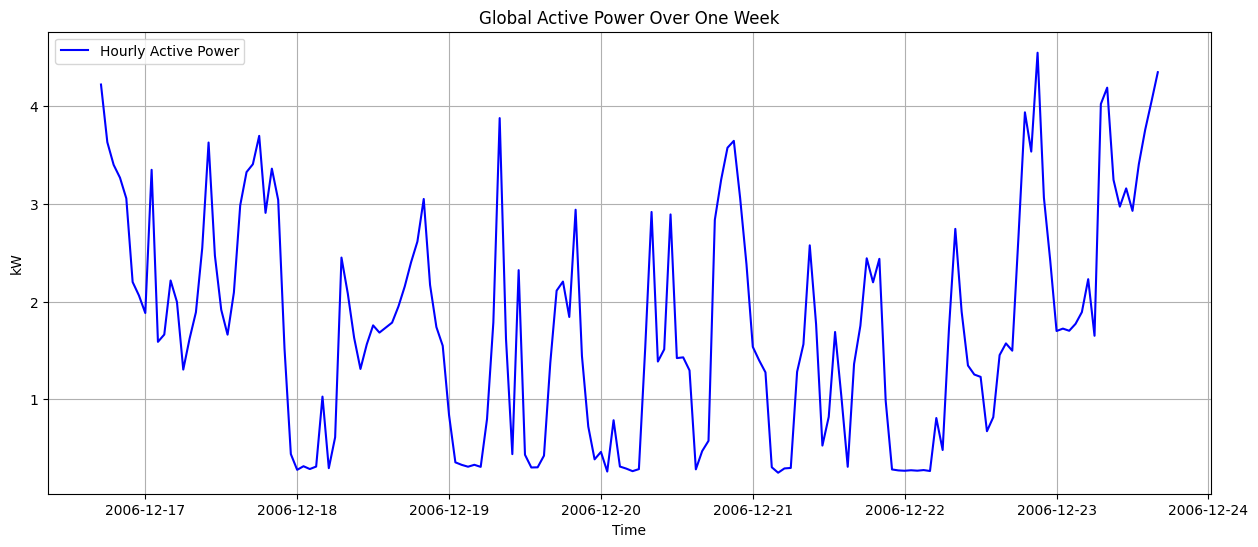

In [ ]:
# 4. EDA Visualizations
plt.figure(figsize=(15, 6))
plt.plot(data_hourly['Global_active_power'].head(24 * 7), label='Hourly Active Power', color='blue')
plt.title('Global Active Power Over One Week')
plt.xlabel('Time')
plt.ylabel('kW')
plt.legend()
plt.grid(True)
plt.show()


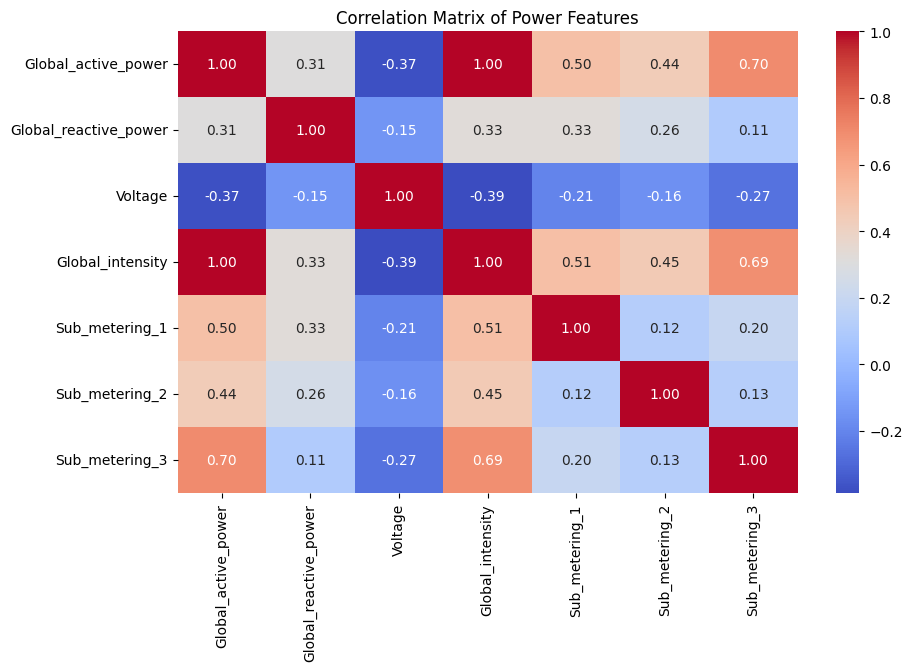

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data_hourly.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Power Features')
plt.show()

# **Feature Engineering**

In [ ]:
# 1. Feature scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data_hourly)

In [ ]:
# 2. Function to create sequential time window datasets
def create_sequences(data, target_col_idx, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, target_col_idx])
    return np.array(X), np.array(y)

In [ ]:
# Global_active_power is the first column (index 0)
X, y = create_sequences(scaled_data, target_col_idx=0, seq_length=24)

In [ ]:
# 3. Train/Validation/Test Split (Time-series split)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (24195, 24, 7), Val shape: (5184, 24, 7), Test shape: (5186, 24, 7)


# **Model Building**

In [ ]:
# 4. Model Building & Training function
def build_and_train(model_type, X_train, y_train, X_val, y_val, epochs=5, batch_size=64):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(SimpleRNN(50, activation='tanh'))

    elif model_type == 'LSTM':
        model.add(LSTM(50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(LSTM(50, activation='tanh'))

    elif model_type == 'GRU':
        model.add(GRU(50, activation='tanh', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(0.2))
        model.add(GRU(50, activation='tanh'))

    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mse')
    print(f"\n--- Training {model_type} Model ---")
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=1)
    return model, history

In [ ]:
# Train all three architectures
rnn_model, rnn_hist = build_and_train('RNN', X_train, y_train, X_val, y_val, epochs=5)
lstm_model, lstm_hist = build_and_train('LSTM', X_train, y_train, X_val, y_val, epochs=5)
gru_model, gru_hist = build_and_train('GRU', X_train, y_train, X_val, y_val, epochs=5)


--- Training RNN Model ---
Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


379/379 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0509 - val_loss: 0.0086
Epoch 2/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0146 - val_loss: 0.0089
Epoch 3/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0116 - val_loss: 0.0084
Epoch 4/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0106 - val_loss: 0.0087
Epoch 5/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0100 - val_loss: 0.0090

--- Training LSTM Model ---
Epoch 1/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0142 - val_loss: 0.0093
Epoch 2/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0099 - val_loss: 0.0084
Epoch 3/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0092 - val_loss: 0.0085
Epoch 4/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0089 - val_loss: 0.0080
Epoch 5/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0086 - val_loss: 0.0078

--- Training GRU Model ---
Epoch 1/5
379/379 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0121 - val_loss: 0.0088
Epoch 2/5
3

# **Model Evaluation**

In [ ]:
# 5. Evaluate and Compare Models
models = {'Vanilla RNN': rnn_model, 'LSTM': lstm_model, 'GRU': gru_model}
results = {}

for name, model in models.items():
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    results[name] = {'MSE': mse, 'MAE': mae, 'model': model, 'preds': predictions}
    print(f"{name} - Test MSE: {mse:.5f}, Test MAE: {mae:.5f}")

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Vanilla RNN - Test MSE: 0.00722, Test MAE: 0.06899
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
LSTM - Test MSE: 0.00586, Test MAE: 0.05532
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
GRU - Test MSE: 0.00594, Test MAE: 0.05496


In [ ]:
# Find the best model based on lowest MSE
best_model_name = min(results, key=lambda k: results[k]['MSE'])
best_model = results[best_model_name]['model']
print(f"\nBest Model is: {best_model_name}")


Best Model is: LSTM


In [ ]:
# Save the best model using native Keras format and the scaler for deployment
best_model.save('best_power_forecast_model.keras')
joblib.dump(scaler, 'scaler.pkl')
print("Saved the best model to 'best_power_forecast_model.keras' and scaler to 'scaler.pkl'")

Saved the best model to 'best_power_forecast_model.keras' and scaler to 'scaler.pkl'


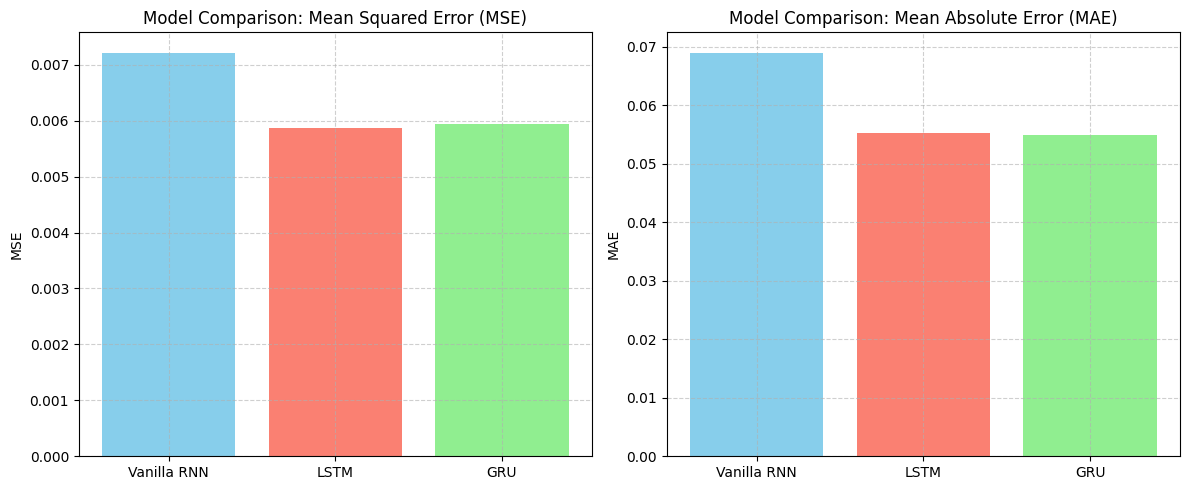

In [ ]:
# Extract metrics for visualization
model_names = list(results.keys())
mses = [results[m]['MSE'] for m in model_names]
maes = [results[m]['MAE'] for m in model_names]

# Create a bar plot comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MSE comparison (ax[0])
ax[0].bar(model_names, mses, color=['skyblue', 'salmon', 'lightgreen'])
ax[0].set_title('Model Comparison: Mean Squared Error (MSE)')
ax[0].set_ylabel('MSE')
ax[0].grid(True, linestyle='--', alpha=0.6)

# MAE comparison (ax[1])
ax[1].bar(model_names, maes, color=['skyblue', 'salmon', 'lightgreen'])
ax[1].set_title('Model Comparison: Mean Absolute Error (MAE)')
ax[1].set_ylabel('MAE')
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Model Testing with GUI**

In [ ]:
!pip install -q gradio

In [ ]:
def predict_interface(g_active, g_reactive, volt, intensity, sub_1, sub_2, sub_3):
    # Simulate past 24 hours of sequence using the input values
    single_timestep = [g_active, g_reactive, volt, intensity, sub_1, sub_2, sub_3]
    dummy_seq = np.repeat([single_timestep], 24, axis=0)

    # Generate dataframe with required features
    cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    input_df = pd.DataFrame(dummy_seq, columns=cols)

    prediction = deploy_inference_pipeline(input_df)
    return f"{prediction:.3f} kW"


In [ ]:
# Setup Gradio GUI Layout
app = gr.Interface(
    fn=predict_interface,
    inputs=[
        gr.Slider(0, 10, value=1.5, label="Global Active Power (kW)"),
        gr.Slider(0, 2, value=0.1, label="Global Reactive Power (kW)"),
        gr.Slider(220, 255, value=240, label="Voltage (V)"),
        gr.Slider(0, 50, value=6.0, label="Global Intensity (A)"),
        gr.Slider(0, 40, value=1.0, label="Sub Metering 1 (Wh)"),
        gr.Slider(0, 40, value=1.0, label="Sub Metering 2 (Wh)"),
        gr.Slider(0, 40, value=10.0, label="Sub Metering 3 (Wh)")
    ],
    outputs=gr.Textbox(label="Predicted Global Active Power for Next Hour"),
    title="Household Power Consumption Predictor",
    description="Adjust the sliders to simulate current conditions and obtain a deep-learning forecast."
)

app.launch(inline=True, share=True, debug = True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ab5d0d982f9e15b445.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://b8cb276708676b748d.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://3430f4a79ea033bc6a.gradio.live
Killing tunnel 127.0.0.1:7862 <> https://ab5d0d982f9e15b445.gradio.live
